# Q10 Decision Tree Sub-Model
**Question:** *What quote comes to mind when you think of this city?*

**Note:** Since this is during the exploration phase I'm tuning with sklearn here. At the end I'll convert the best tree into plain numpy so it can be used in pred.py.

In [1]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data
import re


Step 1: Create the master dataframe

In [2]:
# Load the raw master dataset (same file used for every sub-model)
df_master = pd.read_csv('cleaned_dataset.csv')

# Drop any rows missing labels and reset the index to establish absolute row positions
df_master = df_master.dropna(subset=['Label']).reset_index(drop=True)

df_master.describe()


,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Step 2: Data split (identical code to Q5 -- same code to be used for all sub-models)

In [4]:
# Capture a master index array representing every single row position, and randomize rows
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

master_indices = np.arange(len(df_master))
labels = df_master['Label']

# Print the first 20 rows of the shuffled dataset to verify randomization
print("=== SHUFFLE VERIFICATION REPORT ===")
print(df_master[['Label']].head(20))

print("\n=== CLASS DISTRIBUTION IN TOP 20 ROWS ===")
print(df_master['Label'].head(20).value_counts())

=== SHUFFLE VERIFICATION REPORT ===
             Label
0    New York City
1            Paris
2   Rio de Janeiro
3   Rio de Janeiro
4    New York City
5   Rio de Janeiro
6            Dubai
7            Paris
8   Rio de Janeiro
9    New York City
10  Rio de Janeiro
11           Paris
12   New York City
13  Rio de Janeiro
14           Paris
15           Paris
16           Dubai
17           Paris
18           Paris
19           Dubai

=== CLASS DISTRIBUTION IN TOP 20 ROWS ===
Label
Paris             7
Rio de Janeiro    6
New York City     4
Dubai             3
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

# Step A: Isolate 20% of indices for the Final Evaluation/Test Set
train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_indices, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step B: Split the remaining 80% into 70% Training and 10% Validation indices
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=42
)

# Step C: Split the 70% Training into 80% sub-model training + 20% sub-model validation
labels_train_pool = labels[global_train_idx]
train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=42
)

print("=== GLOBAL INDEX SPLIT REGISTRY (identical to Q5) ===")
print(f"Training Row Indices (70%):  {len(global_train_idx)} rows")
print(f"Validation Row Indices (10%): {len(global_val_idx)} rows")
print(f"Evaluation Row Indices (20%): {len(global_test_idx)} rows")
print(f"Sub-model Training Row Indices (80% of 70%):  {len(train_idx)} rows")
print(f"Sub-model Validation Row Indices (20% of 70%): {len(val_idx)} rows")


=== GLOBAL INDEX SPLIT REGISTRY (identical to Q5) ===
Training Row Indices (70%):  1022 rows
Validation Row Indices (10%): 147 rows
Evaluation Row Indices (20%): 293 rows
Sub-model Training Row Indices (80% of 70%):  817 rows
Sub-model Validation Row Indices (20% of 70%): 205 rows


Step 3: Building keyword features for Q10

Create encoding for Q10 data by turning each keyword into its own indicator (0/1) feature: 1 if the word appears anywhere in that response's Q10 text, 0 otherwise. The keywords come from data + visualizations.xlsx (Q10) sheet, where we already counted the most frequent keywords per city.

In [6]:
city_keywords = {
    'Dubai': ['rich', 'money', 'come', 'habibi', 'world', 'burj', 'oil', 'tallest', 'khalifa', 'desert'],
    'Paris': ['love', 'tower', 'oui', 'eiffel', 'baguette', 'romance', 'romantic', 'world', 'always', 'fashion'],
    'New York City': ['dreams', 'made', 'concrete', 'jungle', 'never', 'sleeps', 'im', 'big', 'apple', 'here'],
    'Rio de Janeiro': ['football', 'life', 'brazil', 'de', 'carnival', 'soccer', 'beautiful', 'party', 'samba', 'jesus'],
}

# Flatten into one ordered (no duplicates) keyword list
feature_names = []
for kw_list in city_keywords.values():
    for kw in kw_list:
        if kw not in feature_names:
            feature_names.append(kw)

print(f"Total indicator features: {len(feature_names)}")
print(feature_names)


Total indicator features: 39
['rich', 'money', 'come', 'habibi', 'world', 'burj', 'oil', 'tallest', 'khalifa', 'desert', 'love', 'tower', 'oui', 'eiffel', 'baguette', 'romance', 'romantic', 'always', 'fashion', 'dreams', 'made', 'concrete', 'jungle', 'never', 'sleeps', 'im', 'big', 'apple', 'here', 'football', 'life', 'brazil', 'de', 'carnival', 'soccer', 'beautiful', 'party', 'samba', 'jesus']


In [7]:
# Fill missing Q10 responses with an empty string
df_master['Q10'] = df_master['Q10'].fillna('')

# Lowercase and strip punctuation
df_master['Q10_clean'] = (
    df_master['Q10'].astype(str)
    .str.lower()
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
)

# One indicator column per keyword
q10_features = pd.DataFrame(index=df_master.index)
for kw in feature_names:
    pattern = r'\b' + re.escape(kw) + r'\b'
    q10_features[kw] = df_master['Q10_clean'].str.contains(pattern, regex=True).astype(int)

# Check if feature columns already exist in df_master and drop them before joining
# This happens if the cell is run multiple times
existing_feature_columns = [col for col in feature_names if col in df_master.columns]
if existing_feature_columns:
    df_master = df_master.drop(columns=existing_feature_columns)

df_master = df_master.join(q10_features)
df_master = df_master.drop(columns=['Q10_clean'])

print("--- Indicator Features (First 5 Rows) ---")
print(q10_features.head())

--- Indicator Features (First 5 Rows) ---
   rich  money  come  habibi  world  burj  oil  tallest  khalifa  desert  ...  \
0     0      0     0       0      0     0    0        0        0       0  ...   
1     0      0     0       0      0     0    0        0        0       0  ...   
2     0      0     0       0      0     0    0        0        0       0  ...   
3     0      0     0       0      0     0    0        0        0       0  ...   
4     0      0     0       0      0     0    0        0        0       0  ...   

   football  life  brazil  de  carnival  soccer  beautiful  party  samba  \
0         0     0       0   0         0       0          0      0      0   
1         0     0       0   0         0       0          1      0      0   
2         0     0       0   0         0       0          0      0      0   
3         0     1       0   0         1       0          0      0      0   
4         0     0       0   0         0       0          0      0      0   

   jesus  
0  

Step 4: Q10 data exploration.

In [8]:
train_analysis_df = df_master.loc[global_train_idx]
print(train_analysis_df['Label'].value_counts())


Label
New York City     256
Dubai             256
Paris             255
Rio de Janeiro    255
Name: count, dtype: int64


In [9]:
# Crosstab a sample of keywords against the label, same pattern as pd.crosstab in the lab
for fet in ['burj', 'eiffel', 'samba', 'dreams', 'world']:
    print(pd.crosstab(train_analysis_df['Label'], train_analysis_df[fet]))
    print()


burj              0   1
Label                  
Dubai           246  10
New York City   256   0
Paris           255   0
Rio de Janeiro  255   0

eiffel            0   1
Label                  
Dubai           256   0
New York City   256   0
Paris           239  16
Rio de Janeiro  255   0

samba             0  1
Label                 
Dubai           256  0
New York City   256  0
Paris           255  0
Rio de Janeiro  247  8

dreams            0   1
Label                  
Dubai           253   3
New York City   208  48
Paris           255   0
Rio de Janeiro  254   1

world             0   1
Label                  
Dubai           243  13
New York City   252   4
Paris           244  11
Rio de Janeiro  248   7



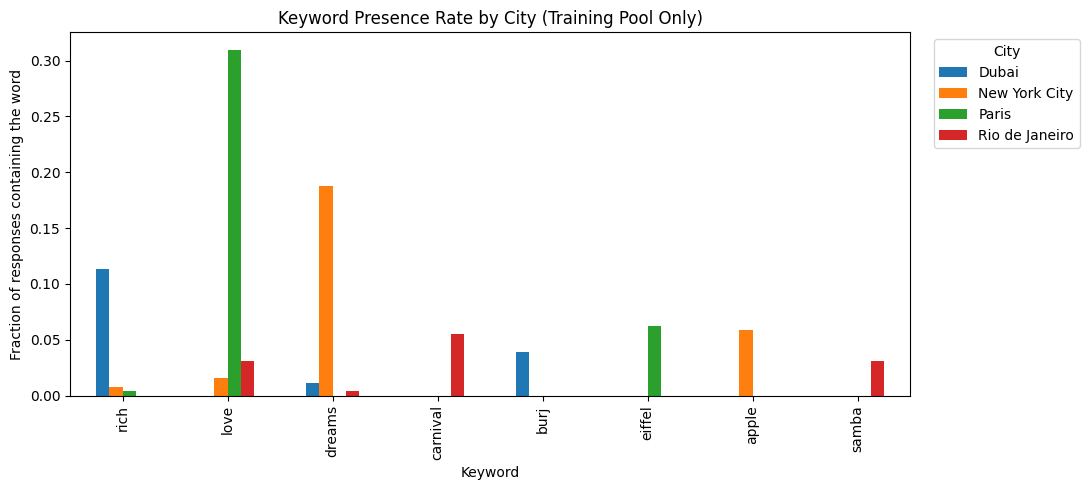

In [10]:
# Mean keyword-presence rate per city, visualized as a grouped bar chart
sample_keywords = ['rich', 'love', 'dreams', 'carnival', 'burj', 'eiffel', 'apple', 'samba']
keyword_rate_by_city = train_analysis_df.groupby('Label')[sample_keywords].mean()

keyword_rate_by_city.T.plot(kind='bar', figsize=(11, 5))
plt.title('Keyword Presence Rate by City (Training Pool Only)')
plt.ylabel('Fraction of responses containing the word')
plt.xlabel('Keyword')
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Step 5: Data splitting for Q10

In [11]:
X = df_master[feature_names].to_numpy()
t = df_master['Label'].to_numpy()

X_train, t_train = X[train_idx], t[train_idx]
X_val,   t_val   = X[val_idx],   t[val_idx]

print(X_train.shape, X_val.shape)


(817, 39) (205, 39)


Step 6: Fit a DecisionTreeClassifier

Use entropy as the split criterion, fit on the sub-model training split, and report training/validation accuracy via .score().

In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree.fit(X_train, t_train)

print('Training Accuracy:', tree.score(X_train, t_train))
print('Validation Accuracy:', tree.score(X_val, t_val))


Training Accuracy: 0.3953488372093023
Validation Accuracy: 0.3951219512195122


Visualize the tree

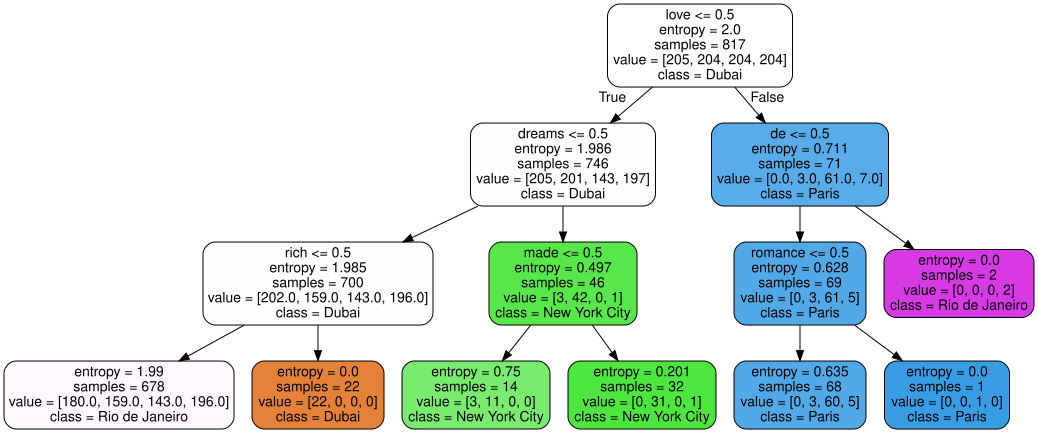

In [13]:
from sklearn import tree as treeViz
import graphviz
from IPython.display import display

def visualize_tree(model, max_depth=5):
    dot_data = treeViz.export_graphviz(
        model,
        feature_names=feature_names,
        max_depth=max_depth,
        class_names=model.classes_,
        filled=True,
        rounded=True,
    )
    return display(graphviz.Source(dot_data))

visualize_tree(tree)


In [14]:
example_idx = 5
print(dict(zip(feature_names, X_train[example_idx])))
print('True label:', t_train[example_idx])
print('Predicted label:', tree.predict(X_train[example_idx:example_idx+1])[0])


{'rich': np.int64(0), 'money': np.int64(0), 'come': np.int64(0), 'habibi': np.int64(0), 'world': np.int64(0), 'burj': np.int64(0), 'oil': np.int64(0), 'tallest': np.int64(0), 'khalifa': np.int64(0), 'desert': np.int64(0), 'love': np.int64(0), 'tower': np.int64(0), 'oui': np.int64(0), 'eiffel': np.int64(0), 'baguette': np.int64(0), 'romance': np.int64(0), 'romantic': np.int64(0), 'always': np.int64(0), 'fashion': np.int64(0), 'dreams': np.int64(1), 'made': np.int64(0), 'concrete': np.int64(0), 'jungle': np.int64(0), 'never': np.int64(0), 'sleeps': np.int64(0), 'im': np.int64(0), 'big': np.int64(0), 'apple': np.int64(0), 'here': np.int64(0), 'football': np.int64(0), 'life': np.int64(0), 'brazil': np.int64(0), 'de': np.int64(0), 'carnival': np.int64(0), 'soccer': np.int64(0), 'beautiful': np.int64(0), 'party': np.int64(0), 'samba': np.int64(0), 'jesus': np.int64(0)}
True label: New York City
Predicted label: New York City


Step 7: Hyperparameter tuning via grid search

In [15]:
def build_all_models(max_depths, min_samples_splits, criterion,
                      X_train=X_train, t_train=t_train, X_valid=X_val, t_valid=t_val):
    """
    Builds one DecisionTreeClassifier per (max_depth, min_samples_split) combination and
    records training + validation accuracy for each, for a fixed split criterion.
    """
    out = {}
    for d in max_depths:
        for s in min_samples_splits:
            out[(d, s)] = {}
            tree = DecisionTreeClassifier(max_depth=d, min_samples_split=s, criterion=criterion)
            tree.fit(X_train, t_train)
            out[(d, s)]['val'] = tree.score(X_valid, t_valid)
            out[(d, s)]['train'] = tree.score(X_train, t_train)
    return out


In [16]:
criterions = ['entropy', 'gini']
max_depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
min_samples_splits = [2, 4, 8, 16, 32, 64, 128]

grid_results = {}
for criterion in criterions:
    print(f"\nUsing criterion {criterion}")
    res = build_all_models(max_depths, min_samples_splits, criterion)
    grid_results[criterion] = res

    best_val_score, best_params = -1, None
    for d, s in res:
        if res[(d, s)]['val'] > best_val_score:
            best_val_score, best_params = res[(d, s)]['val'], (d, s)

    print(f"Best parameters: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
    print(f"Training accuracy: {res[best_params]['train']:.4f}")
    print(f"Validation accuracy: {res[best_params]['val']:.4f}")



Using criterion entropy
Best parameters: max_depth=None, min_samples_split=2
Training accuracy: 0.6095
Validation accuracy: 0.5854

Using criterion gini
Best parameters: max_depth=None, min_samples_split=2
Training accuracy: 0.6095
Validation accuracy: 0.5854


In [17]:
FINAL_CRITERION = 'entropy'
FINAL_MAX_DEPTH = None
FINAL_MIN_SAMPLES_SPLIT = 2


Step 8: Report training/validation/test accuracies for the final Q10 model

In [18]:
X_train = df_master.loc[train_idx, feature_names].to_numpy()
t_train = df_master.loc[train_idx, 'Label'].to_numpy()

final_tree = DecisionTreeClassifier(
    criterion=FINAL_CRITERION, max_depth=FINAL_MAX_DEPTH, min_samples_split=FINAL_MIN_SAMPLES_SPLIT
)
final_tree.fit(X_train, t_train)

train_acc = final_tree.score(X_train, t_train) * 100
val_acc   = final_tree.score(X_val, t_val) * 100

print("==================================================")
print(" Q10 DECISION TREE ACCURACY REPORT ")
print("==================================================")
print(f"Hyperparameters: criterion={FINAL_CRITERION} | max_depth={FINAL_MAX_DEPTH} | "
      f"min_samples_split={FINAL_MIN_SAMPLES_SPLIT}\n")
print(f"Training Accuracy (70% Pool):      {train_acc:.2f}%")
print(f"Validation Accuracy (Set B - 10%):  {val_acc:.2f}%")
print("==================================================")


 Q10 DECISION TREE ACCURACY REPORT 
Hyperparameters: criterion=entropy | max_depth=None | min_samples_split=2

Training Accuracy (70% Pool):      60.95%
Validation Accuracy (Set B - 10%):  58.54%


Our optimized decision tree sub-model for Q10 achieved a final validation accuracy of 58.54%.

In [19]:
t_ = final_tree.tree_
classes_ = final_tree.classes_

print("feature indices per node:", t_.feature[:10], "...")
print("thresholds per node:", t_.threshold[:10], "...")
print("classes:", classes_)


feature indices per node: [10 19  0 24  3 29 32  1 13 27] ...
thresholds per node: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5] ...
classes: ['Dubai' 'New York City' 'Paris' 'Rio de Janeiro']


In [22]:
def sklearn_free_predict(X, feature=t_.feature, threshold=t_.threshold,
                          children_left=t_.children_left, children_right=t_.children_right,
                          value=t_.value, classes=classes_):
    """
    Pure numpy/pandas re-implementation of sklearn's DecisionTreeClassifier.predict,
    using only the fitted tree's raw arrays. Safe to copy into pred.py.
    """
    preds = []
    for x in X:
        node = 0
        while children_left[node] != children_right[node]:  # not a leaf
            if x[feature[node]] <= threshold[node]:
                node = children_left[node]
            else:
                node = children_right[node]
        preds.append(classes[np.argmax(value[node])])
    return np.array(preds)


# Sanity check: this must match final_tree.predict(...) exactly
# sklearn_preds = final_tree.predict(X_test)
# manual_preds = sklearn_free_predict(X_test)
# print("Predictions match exactly:", np.array_equal(sklearn_preds, manual_preds))


Notes for pred.py:

1. Save `t_.feature`, `t_.threshold`, `t_.children_left`, `t_.children_right`, `t_.value`, and `classes_` to a small file (e.g. `.npz` via `np.savez`, which is fine under the numpy-only rule) -- these arrays are tiny for a shallow tree, well within the 10MB budget.
2. Copy `sklearn_free_predict` into `pred.py` unchanged; it only uses `numpy`.
3. Re-implement the Step 3 keyword-extraction logic in `pred.py` so `predict_all(test_csv)` can turn a raw test CSV's `Q10` column into the same feature matrix before calling `sklearn_free_predict`.
4. This Q10 tree is one sub-model -- combine its predictions with Q5's (and any others) at the **late-fusion validation** stage using `global_val_idx`.